<a href="https://colab.research.google.com/github/Vaishnavi943/ML_Project/blob/main/Calc_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Calculate_Insurance**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df.head()








,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

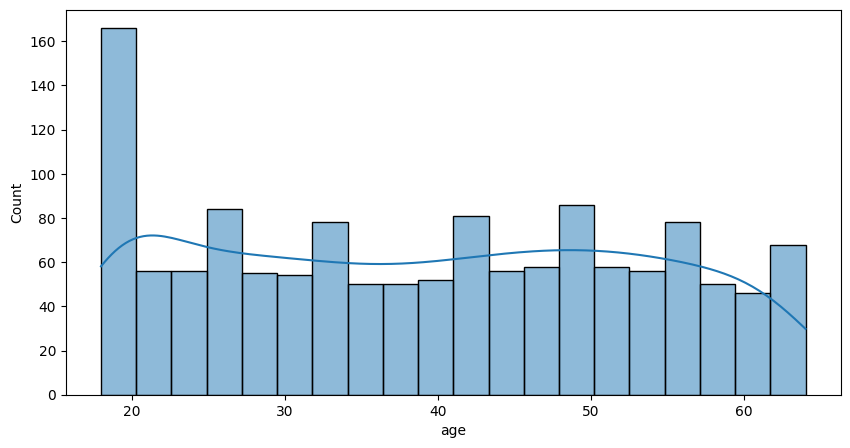

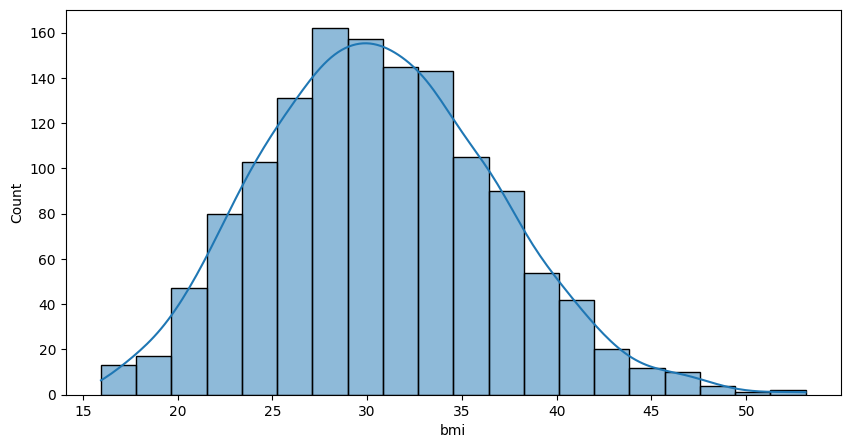

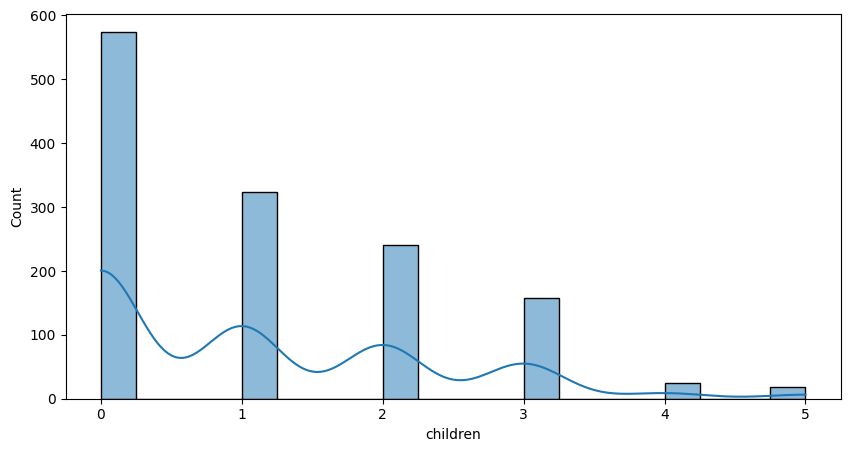

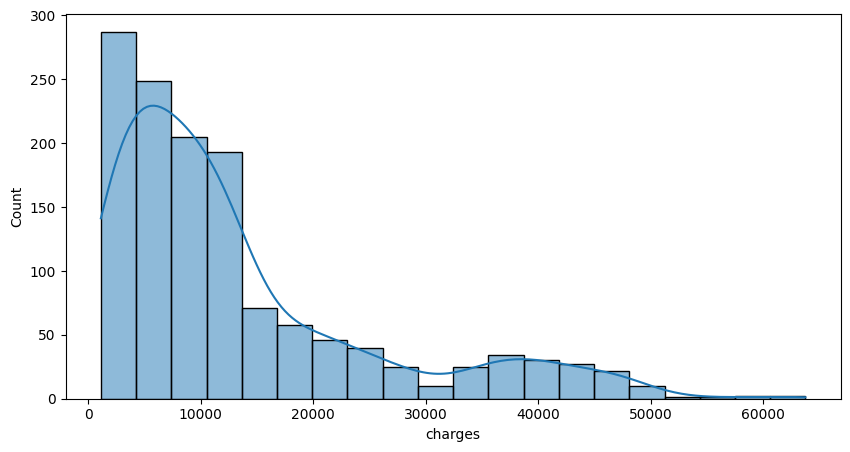

In [ ]:
numeric_col = ['age', 'bmi', 'children','charges']
for col in numeric_col:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True, bins=20)
  plt.show()

<Axes: xlabel='children', ylabel='count'>

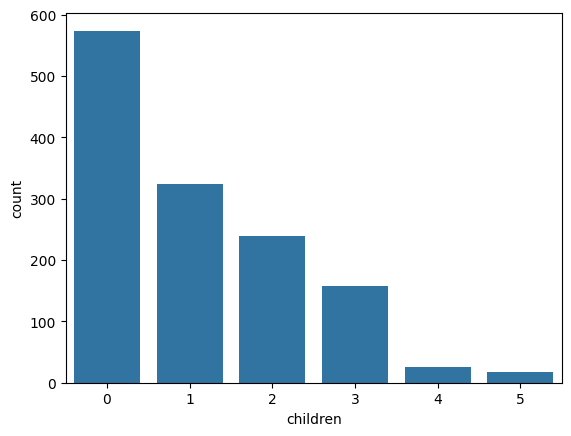

In [ ]:
sns.countplot(x = df['children'])

<Axes: xlabel='smoker', ylabel='count'>

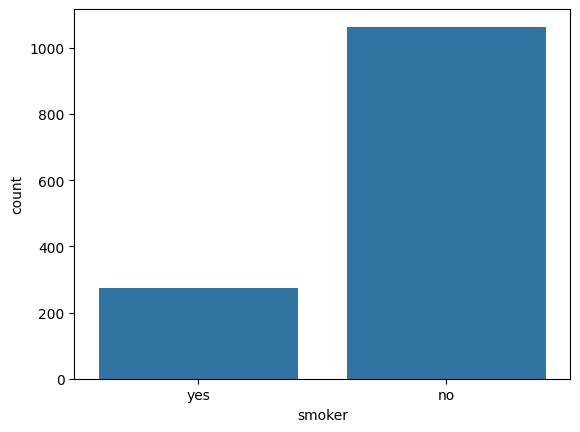

In [ ]:
sns.countplot(x = df['smoker'])

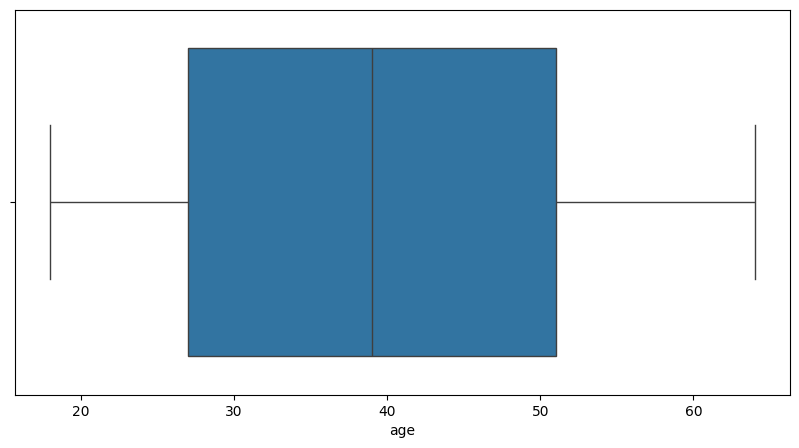

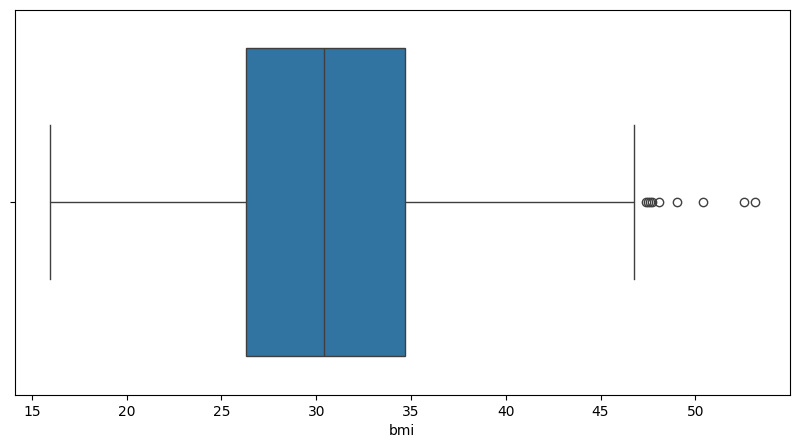

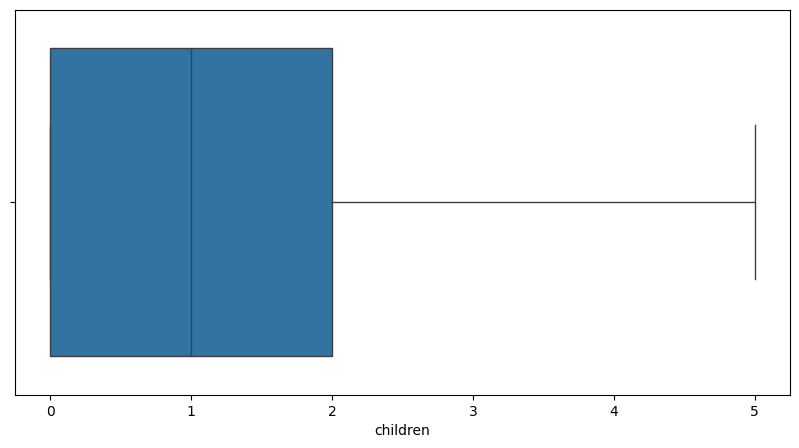

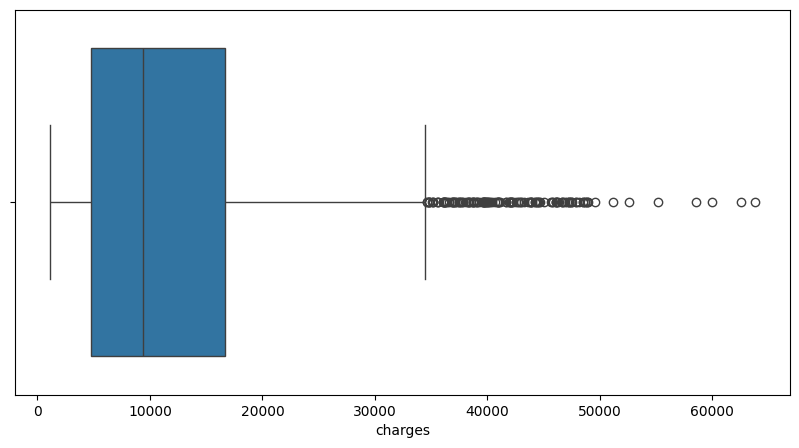

In [ ]:
for col in numeric_col:
  plt.figure(figsize=(10,5))
  sns.boxplot(x = df[col])
  plt.show()

<Axes: >

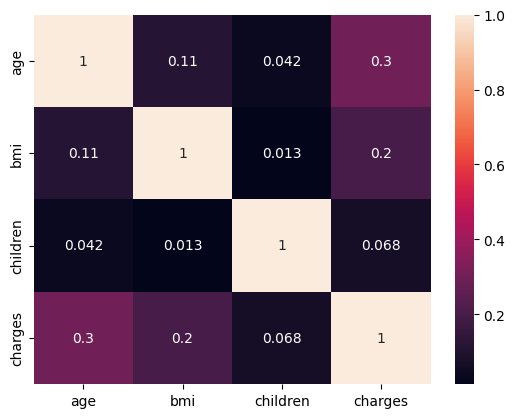

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

Data cleaning & preprocessing

In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned.shape

(1338, 7)

In [ ]:
df_cleaned.drop_duplicates(inplace=True)
print(df_cleaned.shape)

(1337, 7)


In [ ]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
print(df_cleaned['sex'].value_counts())

df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0, "female" : 1})
print(df_cleaned.tail())

sex
male      675
female    662
Name: count, dtype: int64
      age  sex    bmi  children smoker     region     charges
1333   50    0  30.97         3     no  northwest  10600.5483
1334   18    1  31.92         0     no  northeast   2205.9808
1335   18    1  36.85         0     no  southeast   1629.8335
1336   21    1  25.80         0     no  southwest   2007.9450
1337   61    1  29.07         0    yes  northwest  29141.3603


In [ ]:
print(df_cleaned['smoker'].value_counts())

df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 0, "yes" : 1})
print(df_cleaned.head())

smoker
no     1063
yes     274
Name: count, dtype: int64
   age  sex     bmi  children  smoker     region      charges
0   19    1  27.900         0       1  southwest  16884.92400
1   18    0  33.770         1       0  southeast   1725.55230
2   28    0  33.000         3       0  southeast   4449.46200
3   33    0  22.705         0       0  northwest  21984.47061
4   32    0  28.880         0       0  northwest   3866.85520


In [ ]:
df_cleaned.rename(columns={
    "sex" : "is_female",
    "smoker" : "is_smoker"
}, inplace=True )

print(df_cleaned.head())

   age  is_female     bmi  children  is_smoker     region      charges
0   19          1  27.900         0          1  southwest  16884.92400
1   18          0  33.770         1          0  southeast   1725.55230
2   28          0  33.000         3          0  southeast   4449.46200
3   33          0  22.705         0          0  northwest  21984.47061
4   32          0  28.880         0          0  northwest   3866.85520


In [ ]:
df_cleaned.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)
print(df_cleaned.head())

   age  is_female     bmi  children  is_smoker      charges  region_northwest  \
0   19          1  27.900         0          1  16884.92400             False   
1   18          0  33.770         1          0   1725.55230             False   
2   28          0  33.000         3          0   4449.46200             False   
3   33          0  22.705         0          0  21984.47061              True   
4   32          0  28.880         0          0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [ ]:
df_cleaned = df_cleaned.astype('int')

print(df_cleaned)

      age  is_female  bmi  children  is_smoker  charges  region_northwest  \
0      19          1   27         0          1    16884                 0   
1      18          0   33         1          0     1725                 0   
2      28          0   33         3          0     4449                 0   
3      33          0   22         0          0    21984                 1   
4      32          0   28         0          0     3866                 1   
...   ...        ...  ...       ...        ...      ...               ...   
1333   50          0   30         3          0    10600                 1   
1334   18          1   31         0          0     2205                 0   
1335   18          1   36         0          0     1629                 0   
1336   21          1   25         0          0     2007                 0   
1337   61          1   29         0          1    29141                 1   

      region_southeast  region_southwest  
0                    0          

Feature Engineering & Extraction

In [ ]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

print(df_cleaned.head())

   age  is_female  bmi  children  is_smoker  charges  region_northwest  \
0   19          1   27         0          1    16884                 0   
1   18          0   33         1          0     1725                 0   
2   28          0   33         3          0     4449                 0   
3   33          0   22         0          0    21984                 1   
4   32          0   28         0          0     3866                 1   

   region_southeast  region_southwest bmi_category  
0                 0                 1   Overweight  
1                 1                 0        Obese  
2                 1                 0        Obese  
3                 0                 0       Normal  
4                 0                 0   Overweight  


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'] , drop_first=True)


In [ ]:
df_cleaned = df_cleaned.astype('int')

print(df_cleaned.head())

   age  is_female  bmi  children  is_smoker  charges  region_northwest  \
0   19          1   27         0          1    16884                 0   
1   18          0   33         1          0     1725                 0   
2   28          0   33         3          0     4449                 0   
3   33          0   22         0          0    21984                 1   
4   32          0   28         0          0     3866                 1   

   region_southeast  region_southwest  bmi_category_Normal  \
0                 0                 1                    0   
1                 1                 0                    0   
2                 1                 0                    0   
3                 0                 0                    1   
4                 0                 0                    0   

   bmi_category_Overweight  bmi_category_Obese  
0                        1                   0  
1                        0                   1  
2                        0         

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
cols = ['age', 'bmi', 'children']
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

print(df_cleaned.head())

        age  is_female       bmi  children  is_smoker  charges  \
0 -1.440418          1 -0.517949 -0.909234          1    16884   
1 -1.511647          0  0.462463 -0.079442          0     1725   
2 -0.799350          0  0.462463  1.580143          0     4449   
3 -0.443201          0 -1.334960 -0.909234          0    21984   
4 -0.514431          0 -0.354547 -0.909234          0     3866   

   region_northwest  region_southeast  region_southwest  bmi_category_Normal  \
0                 0                 0                 1                    0   
1                 0                 1                 0                    0   
2                 0                 1                 0                    0   
3                 1                 0                 0                    1   
4                 1                 0                 0                    0   

   bmi_category_Overweight  bmi_category_Obese  
0                        1                   0  
1                       

In [ ]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [ ]:
from scipy.stats import pearsonr
# pearson correlation calc

# list of feature to check against the target
selected_features = [
    'age', 'is_female', 'bmi', 'children', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

print(correlation_df)

                    Feature  Pearson Correlation
0                       age             0.298309
1                 is_female            -0.058046
2                       bmi             0.196236
3                  children             0.067390
4                 is_smoker             0.787234
5          region_northwest            -0.038695
6          region_southeast             0.073577
7          region_southwest            -0.043637
8       bmi_category_Normal            -0.104042
9   bmi_category_Overweight            -0.120601
10       bmi_category_Obese             0.200348


In [ ]:
# chi-square test
from scipy.stats import chi2_contingency

cat_feature = [
    'is_female', 'is_smoker',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]


In [ ]:
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

print(df_cleaned['charges_bin'] )

0       3
1       0
2       0
3       3
4       0
       ..
1333    2
1334    0
1335    0
1336    0
1337    3
Name: charges_bin, Length: 1337, dtype: int64


In [ ]:
alpha = 0.05
chi2_results = {}

for col in cat_feature:
  contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
  chi2_stats, p_val, dof, expected = chi2_contingency(contingency)
  decision = "Reject null (keep feature)" if p_val < alpha else "accept null (drop feature)"
  chi2_results[col] = {
      'chi2_statics': chi2_stats,
      'p_val': p_val,
      'decision': decision
  }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df  = chi2_df.sort_values(by='p_val')
print(chi2_df)

                        chi2_statics     p_val                    decision
is_smoker                 848.219178       0.0  Reject null (keep feature)
region_southeast           15.998167  0.001135  Reject null (keep feature)
is_female                  10.258784   0.01649  Reject null (keep feature)
bmi_category_Obese          8.515711  0.036473  Reject null (keep feature)
region_southwest            5.091893  0.165191  accept null (drop feature)
bmi_category_Overweight      4.25149  0.235557  accept null (drop feature)
bmi_category_Normal         3.708088   0.29476  accept null (drop feature)
region_northwest             1.13424  0.768815  accept null (drop feature)


In [ ]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southwest', 'bmi_category_Obese']]

print(final_df.head())

        age  is_female       bmi  children  is_smoker  charges  \
0 -1.440418          1 -0.517949 -0.909234          1    16884   
1 -1.511647          0  0.462463 -0.079442          0     1725   
2 -0.799350          0  0.462463  1.580143          0     4449   
3 -0.443201          0 -1.334960 -0.909234          0    21984   
4 -0.514431          0 -0.354547 -0.909234          0     3866   

   region_southwest  bmi_category_Obese  
0                 1                   0  
1                 0                   1  
2                 0                   1  
3                 0                   0  
4                 0                   0  
